In [34]:
import pandas as pd
import joblib
import shap
from sklearn.model_selection import train_test_split

In [35]:
df = pd.read_csv(
    "../data/customer_value_data.csv"
)

In [36]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:

    if df[col].dtype == "object":

        df[col] = le.fit_transform(
            df[col].astype(str)
        )

In [37]:
X = df.drop(
    ["HighValueCustomer", "CustomerValue"],
    axis=1
)

In [38]:
model = joblib.load(
    "../models/xgboost_clv_model.pkl"
)

In [39]:
explainer = shap.TreeExplainer(
    model
)

In [40]:
print("Model Features:")
print(model.get_booster().feature_names)

print("\nCurrent Features:")
print(X.columns.tolist())

print("\nModel Feature Count:")
print(len(model.get_booster().feature_names))

print("\nCurrent Feature Count:")
print(len(X.columns))

Model Features:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'CustomerValue']

Current Features:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Model Feature Count:
22

Current Feature Count:
21


In [41]:
model.get_booster().feature_names

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn',
 'CustomerValue']

In [42]:
X = df.drop(
    ["HighValueCustomer", "CustomerValue"],
    axis=1
)

y = df["HighValueCustomer"]

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [45]:
print(model.get_booster().feature_names)
print(len(model.get_booster().feature_names))

print(X.columns.tolist())
print(len(X.columns))

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
21
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
21


In [46]:
import shap

explainer = shap.TreeExplainer(
    model
)

print("Explainer Ready")

Explainer Ready


In [47]:
shap_values = explainer(
    X
)

print(type(shap_values))

<class 'shap._explanation.Explanation'>


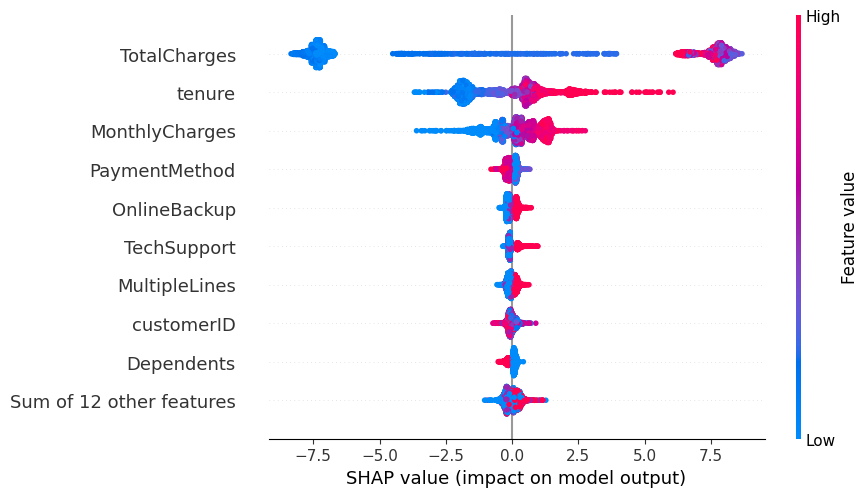

In [48]:
shap.plots.beeswarm(
    shap_values,
    max_display=10
)

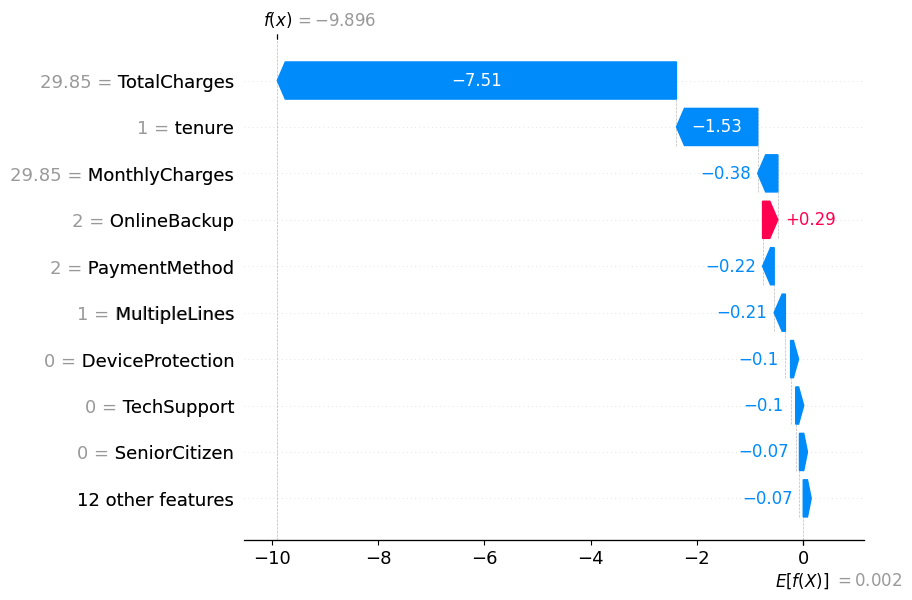

In [49]:
sample = X.iloc[[0]]

sample_shap = explainer(
    sample
)

shap.plots.waterfall(
    sample_shap[0]
)

In [50]:
print(model.get_booster().feature_names)
print(len(model.get_booster().feature_names))

print(X.columns.tolist())
print(len(X.columns))

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
21
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
21
